# Neural Architectures for Video: Human Action Recognition (HAR)

*Notebook created in PyTorch by [Josep López](https://www.linkedin.com/in/yusepp/) for the [UPC School](https://www.talent.upc.edu/ing/) (2025)*

Revisited by [Albert Mosella-Montoro](https://www.linkedin.com/in/albertmosellamontoro) for the [UPC School](https://www.talent.upc.edu/ing/) (2026)

**Duration:** 1 hour and 30 min

This notebook provides a hands-on introduction to video classification with deep learning. You will build a video `Dataset`, implement the core building block of the **R(2+1)D** network — a ResNet-based architecture that factorises a 3D convolution into a spatial (2D) and a temporal (1D) convolution — and train it to recognise human actions from the **UCF101** dataset. Finally, you will benchmark your model against pretrained state-of-the-art networks (R(2+1)D-18 and Swin3D-B), compare their learned feature spaces with **t-SNE**, and analyse their mistakes.

**Note:** This notebook assumes prior knowledge of PyTorch and 2D CNNs. If you are not familiar with convolutional networks, please review the basics of `Conv2d`, residual connections and the training loop before starting.

# Lab Tasks

## Core Tasks

### 1. Video Data Pipeline
- Explore the UCF101 dataset and build a `Dataset` that samples a fixed-length clip from each video.

- Create the `DataLoader`s and visualise a batch of video clips.

### 2. R(2+1)D Network
- Implement the R(2+1)D convolution block that decomposes a 3D convolution into a spatial and a temporal convolution.

- Assemble the R(2+1)D ResNet using the provided residual blocks.

### 3. Training
- Implement the training and validation loops and train the network on UCF101.

### 4. Model Performance Evaluation
- Benchmark your model against pretrained R(2+1)D-18 and Swin3D-B models.

- Compare feature spaces with t-SNE and analyse each model's mistakes.

*For guidance on PyTorch functions, consult the [PyTorch documentation](https://pytorch.org/docs/stable/index.html). Remember to enable GPU acceleration in `Runtime > Change runtime type > Hardware Accelerator`.*


# Dependencies

In [ ]:
%%capture
# Install required packages
!pip install kagglehub tqdm einops mediapy torchmetrics -qqq --quiet

In [ ]:
# Standard library imports
import glob
import os
from typing import Dict, List, Optional, Tuple

# Third-party libraries
import copy

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import mediapy as mp
import cv2
from einops import rearrange
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms.v2 import Compose, Resize, ToDtype, ToImage

# Metrics
import torchmetrics

# Dataset download helper
import kagglehub

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

In [ ]:
%%capture
# Download and extract the UCF101 subset (~1 min)
if not os.path.exists("./ucf101_subset"):
    path = kagglehub.dataset_download("yusepp/ucf101-subset")
    !mkdir -p ./ucf101_subset
    !mv {path}/* ./ucf101_subset
    print("Dataset downloaded and extracted successfully! (./ucf101_subset)")

# Download the pretrained models used in the Model Performance Evaluation section
if not os.path.exists('r2plus1d_18_DEFAULT_finetuned_10_epochs.pth'):
    path = kagglehub.model_download("yusepp/aidl_video_lab/pyTorch/default")
    !mv {path}/* ./


# Video Data Pipeline

The [UCF101](https://www.crcv.ucf.edu/data/UCF101.php) dataset contains 13,320 YouTube clips spanning 101 human action classes (sports, musical instruments, human-object interactions, etc.). To keep the lab within Colab's limits we use a **balanced subset** of the dataset.

Working with video adds a temporal dimension on top of images. Instead of a single frame, each sample is a short **clip** of shape `(C, T, H, W)` — channels, time, height and width. The two key design choices are:

- **Temporal sampling:** how many frames (`T`) we take from each video and how we space them out.
- **Spatial preprocessing:** resizing every frame to a fixed resolution so clips can be batched together.

![Action Recognition Example](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*EvxO1sdZ1DCLfDxQNTiflQ.png)


## Define the Video Dataset

Complete the `UCF101Dataset` below. Most of the I/O is provided; you only need to fill the **frame sampling** and the **final tensor layout**:

- Sample `sequence_length` frames spread uniformly across the whole video.
- Return each clip with the channel-time-height-width layout `(C, T, H, W)` expected by 3D CNNs.

In [ ]:
class UCF101Dataset(Dataset):
    """A PyTorch Dataset for loading and preprocessing UCF101 video data.

    Each item is a tuple (clip, label) where clip has shape (C, T, H, W).
    """

    def __init__(self, data_path: str, sequence_length: int, transforms: Optional[callable] = None) -> None:
        super().__init__()
        self.files = sorted(glob.glob(os.path.join(data_path, "*", "*.avi")))

        # Build the label list from the folder names
        self.activities = sorted(list(set(f.split("/")[-2] for f in self.files)))
        labels = np.array([f.split("/")[-2] for f in self.files])
        _, self.labels = np.unique(labels, return_inverse=True)

        self.sequence_length = sequence_length
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        return self.read_video(self.files[idx]), self.labels[idx]

    def read_video(self, video_path: str) -> torch.Tensor:
        """Read a video and return a clip of shape (C, T, H, W)."""
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # TODO: Compute the indices of the frames to keep, spread uniformly over the video
        stride = ...
        indices = ...

        frames = []
        frame_idx = 0
        while cap.isOpened() and len(frames) < self.sequence_length:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx in indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = frame.astype(np.float32) / 255.0
                frame = np.transpose(frame, (2, 0, 1))   # HWC -> CHW
                frames.append(frame)
            frame_idx += 1
        cap.release()

        # Pad short videos by repeating the last frame
        if len(frames) < self.sequence_length:
            last_frame = frames[-1] if frames else np.zeros((3, 112, 112), dtype=np.float32)
            while len(frames) < self.sequence_length:
                frames.append(last_frame)

        frames = torch.from_numpy(np.stack(frames))   # (T, C, H, W)

        if self.transforms:
            frames = self.transforms(frames)

        # TODO: Rearrange the clip from (T, C, H, W) to the (C, T, H, W) layout expected by 3D convs
        frames = rearrange(frames, ...)


def get_loader(split: str, transforms: callable, shuffle: bool = False,
               batch_size: int = 16, sequence_length: int = 8) -> DataLoader:
    """Create a DataLoader for the given dataset split."""
    dataset = UCF101Dataset(
        data_path=f"./ucf101_subset/{split}",
        sequence_length=sequence_length,
        transforms=transforms,
    )
    return DataLoader(dataset=dataset, batch_size=batch_size, num_workers=2, shuffle=shuffle)

## Visualise a batch

The helper function `visualize_video_batch` (provided) plays a few clips from a batch so you can sanity-check the data pipeline. Build a validation `DataLoader` and display one batch.

In [ ]:
def visualize_video_batch(batch_videos: torch.Tensor, batch_labels: torch.Tensor,
                          activities: List[str] = None, num_videos: int = 4):
    """Display the first few videos of a batch."""
    videos = batch_videos[:num_videos].cpu().numpy()
    labels = batch_labels[:num_videos].cpu().numpy()

    videos_dict = {}
    for i, (video, label) in enumerate(zip(videos, labels)):
        title = f"Video {i + 1}"
        if activities:
            title += f"\nClass: {activities[label]}"
        videos_dict[title] = rearrange(
            ((video - video.min()) / (video.max() - video.min()) * 255).astype(np.uint8),
            "c t h w -> t h w c",
        )
    mp.show_videos(videos_dict, width=320, height=240, fps=4, columns=4, border=True)

In [ ]:
# Basic preprocessing: convert to float tensor and resize every frame to 112x112
transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Resize((112, 112)),
])

# TODO: Create a validation DataLoader (shuffle=True so we see different classes)
loader = ...

# Visualise the first batch
for videos, labels in loader:
    print("Batch shape (B, C, T, H, W):", tuple(videos.shape))
    visualize_video_batch(videos, labels, activities=loader.dataset.activities)
    break

# R(2+1)D Network

A natural way to process video is the **3D convolution**, which slides a `t x h x w` kernel over the clip. However, 3D convolutions have many parameters and are hard to optimise.

The **R(2+1)D** network (Tran et al., 2018) factorises each 3D convolution into two cheaper steps:

1. A **spatial** convolution `1 x h x w` that mixes information *within* each frame.
2. A **temporal** convolution `t x 1 x 1` that mixes information *across* frames.

This decomposition keeps roughly the same number of parameters as a 3D conv while adding an extra non-linearity and being easier to train.

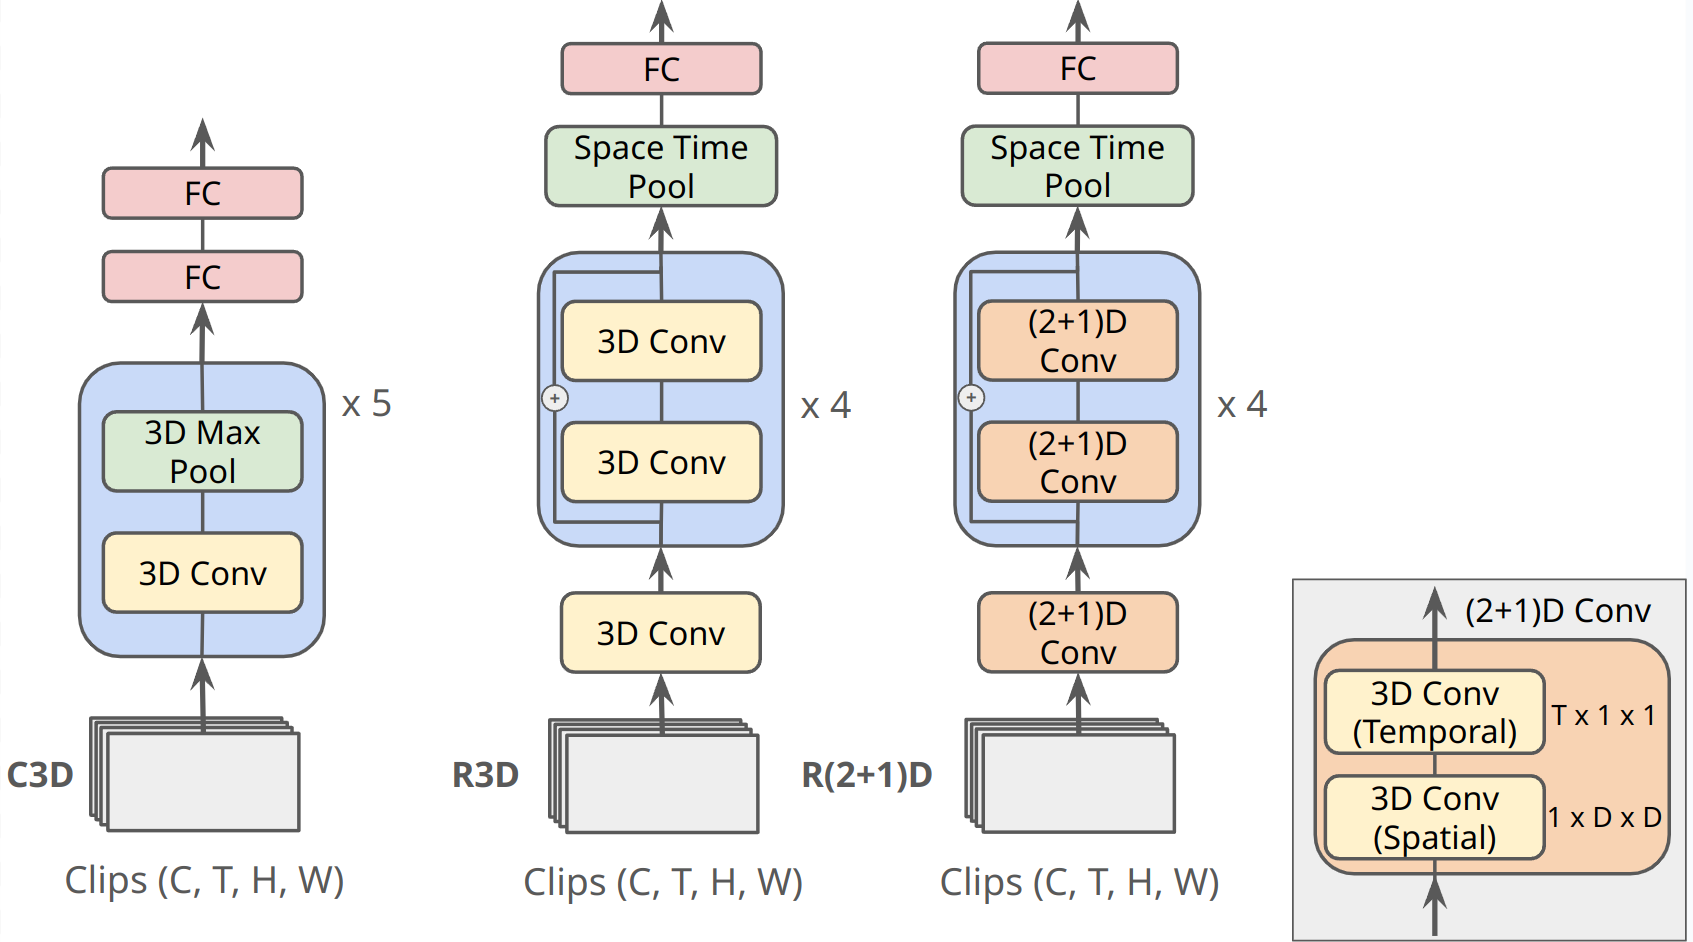

*Comparing C3D, R3D (3D nets) vs R(2+1)D*

The R(2+1)D network enhances video understanding by improving traditional 3D CNNs. It decomposes 3D convolutions into two simpler operations:  

1. **2D Spatial Convolution**: Extracts spatial features (height and width) within each frame.  
2. **1D Temporal Convolution**: Captures motion dynamics across frames (time).

This **decomposition** introduces non-linearity between spatial and temporal processing, improving learning efficiency. **Residual connections** further enhance the model by allowing shortcut paths, enabling stable training and effective feature propagation even in deeper networks.  

The network follows a **ResNet-inspired architecture**, organizing layers into blocks to capture spatial and temporal features hierarchically. It processes video tensors of shape `(batch_size, channels, sequence_size, height, width)` and outputs action class predictions, making it efficient and powerful for video recognition tasks.

**Implementation Note:**
For detailed specifications, refer to the [original paper](https://arxiv.org/pdf/1711.11248).

## Implement the R(2+1)D convolution block

Complete the `R2Plus1DConv` block below. The number of intermediate channels `mid_channels` is computed for you so that the block has a similar parameter count to an equivalent 3D convolution. You need to define:

- the **spatial** branch: a `Conv3d` with kernel `(1, k, k)` (+ BatchNorm + ReLU),
- the **temporal** branch: a `Conv3d` with kernel `(k, 1, 1)` (+ BatchNorm + ReLU),
- the **forward** pass applying spatial then temporal.

The `ResBlock` and the full `R2Plus1DResNet` are provided for you (similar to how the T-Net was provided in the 3D lab).

In [ ]:
class R2Plus1DConv(nn.Module):
    """Factorised (2+1)D convolution: a spatial (2D) conv followed by a temporal (1D) conv."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3,
                 stride: int = 1, padding: int = 1):
        super().__init__()
        k = kernel_size

        # Middle channels chosen to match the parameter count of a full 3D conv
        mid_channels = (in_channels * out_channels * k * k) // \
                       (in_channels * k * k + k * out_channels)

        # TODO: Define the spatial (2D) convolution: Conv3d with kernel (1, k, k) + BatchNorm3d + ReLU
        self.spatial = ...

        # TODO: Define the temporal (1D) convolution: Conv3d with kernel (k, 1, 1) + BatchNorm3d + ReLU
        self.temporal = ...

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Apply the spatial convolution, then the temporal convolution
        x = ...
        x = ...


class ResBlock(nn.Module):
    """Residual block made of two R(2+1)D convolutions plus a shortcut connection."""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv_path = nn.Sequential(
            R2Plus1DConv(in_channels, out_channels, stride=stride),
            R2Plus1DConv(out_channels, out_channels),
        )
        self.shortcut = (
            R2Plus1DConv(in_channels, out_channels, kernel_size=1, stride=stride, padding=0)
            if stride != 1 or in_channels != out_channels else nn.Identity()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.relu(self.conv_path(x) + self.shortcut(x))

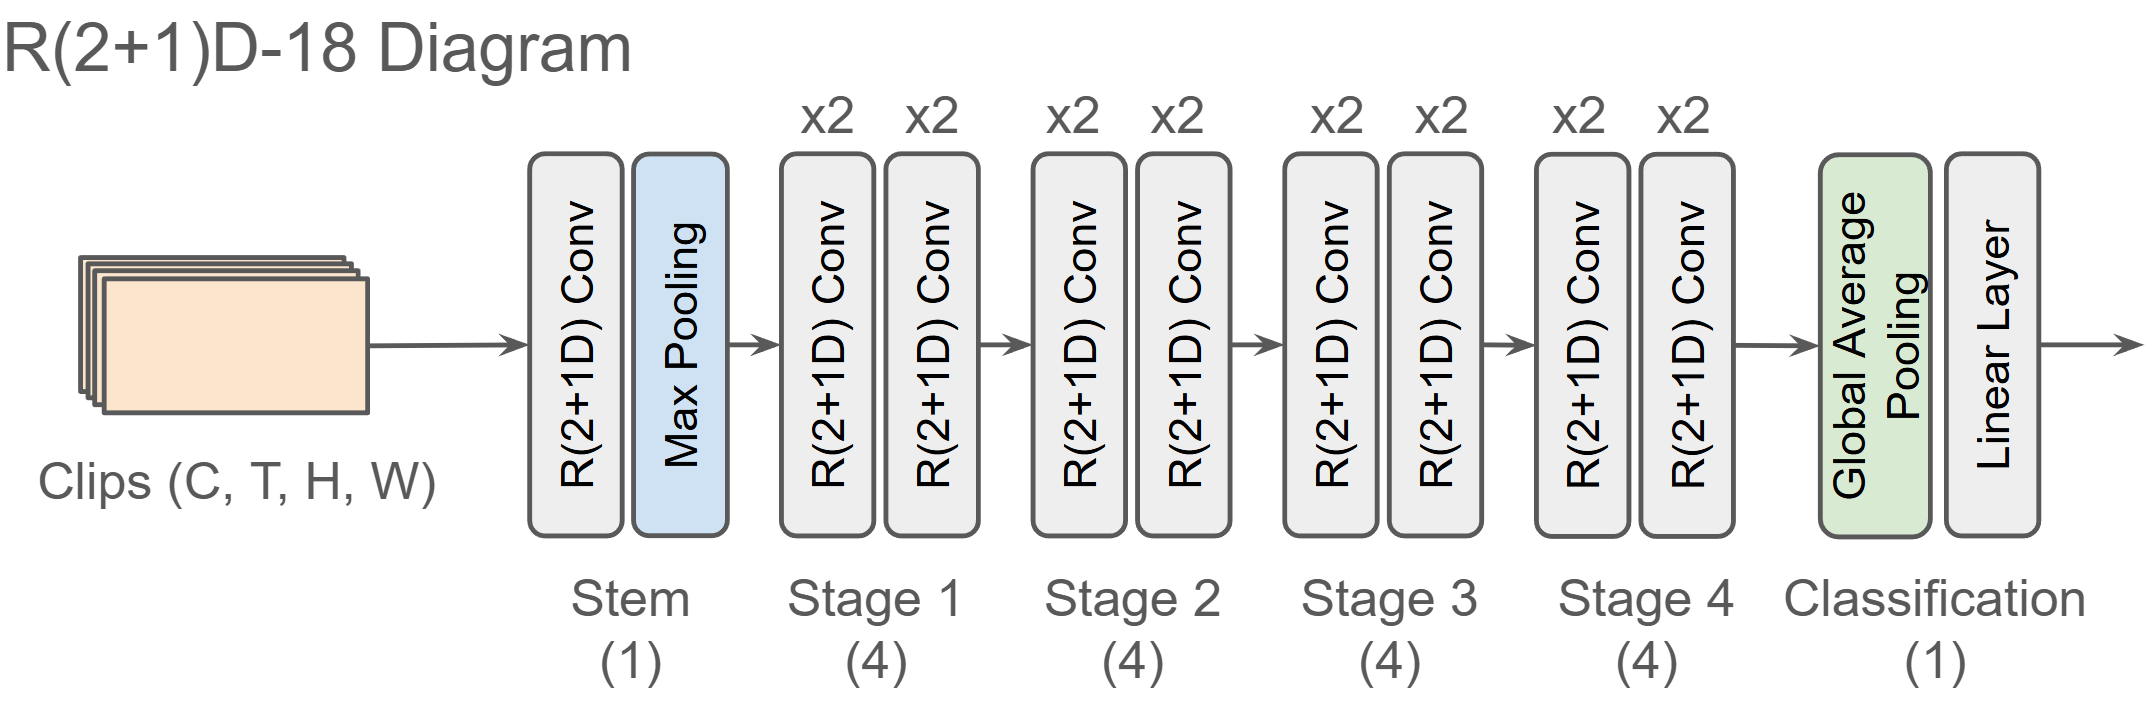

## Assemble the R(2+1)D ResNet

The full network is provided. It stacks a stem, four residual stages and a linear classification head, following the familiar ResNet layout.

In [ ]:
class R2Plus1DResNet(nn.Module):
    """R(2+1)D ResNet for video classification.

    Args:
        blocks: number of residual blocks per stage (e.g. [2, 2, 2, 2] for an 18-layer net).
        num_classes: number of output classes.
    """

    def __init__(self, blocks: List[int], num_classes: int = 101):
        super().__init__()
        self.stem = R2Plus1DConv(3, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool = nn.MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1))

        self.body = nn.Sequential(
            self._make_stage(64, 64, blocks[0], 1),
            self._make_stage(64, 128, blocks[1], 2),
            self._make_stage(128, 256, blocks[2], 2),
            self._make_stage(256, 512, blocks[3], 2),
        )

        self.avgpool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.head = nn.Linear(512, num_classes)

    def _make_stage(self, in_channels: int, out_channels: int, num_blocks: int, stride: int) -> nn.Sequential:
        return nn.Sequential(
            ResBlock(in_channels, out_channels, stride),
            *[ResBlock(out_channels, out_channels) for _ in range(num_blocks - 1)],
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.maxpool(self.stem(x))
        x = self.body(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.head(x)


def create_r2plus1d_10(num_classes: int = 101) -> R2Plus1DResNet:
    """A lightweight 10-layer R(2+1)D ResNet (one block per stage)."""
    return R2Plus1DResNet([1, 1, 1, 1], num_classes)


def count_parameters(model: nn.Module) -> int:
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {num_params:,}")
    return num_params


count_parameters(create_r2plus1d_10(num_classes=101))

**Question:** A standard 3D convolution and the R(2+1)D block can be tuned to use a similar number of parameters. What, then, is the advantage of splitting the 3D convolution into a separate spatial and temporal convolution? Explain it in your own words.

# Training

We now train the R(2+1)D network on UCF101. As in the 3D lab, we use `torchmetrics` to track accuracy and implement a simple `train` / `validate` loop.

## Define Metrics

We track **two** evaluation metrics, both provided by [`torchmetrics`](https://lightning.ai/docs/torchmetrics/stable/) (so we don't reimplement them by hand):

**Accuracy** — the fraction of correctly classified clips. We report it at two levels:
* **top-1**: the highest-scoring class must be the correct one.
* **top-5**: the correct class must be among the 5 highest-scoring classes (useful when many actions look alike).

**F1-Score** — the harmonic mean of precision and recall, averaged across classes (`macro`). Unlike accuracy, it is sensitive to per-class performance, which matters when classes are imbalanced.

**Mathematical Formulas:**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}, \quad \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

where:
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}, \quad \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

We group the three metrics in a [`MetricCollection`](https://lightning.ai/docs/torchmetrics/stable/pages/overview.html#metriccollection) so we can `update` / `compute` / `reset` them all at once. Each metric exposes the same interface used in the 3D lab:
* `update(logits, targets)`: accumulate a batch of predictions,
* `compute()`: return the current values,
* `reset()`: clear the internal state.

In [ ]:
num_classes = 101

from torchmetrics import MetricCollection
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

# Group the metrics so they can be updated/computed/reset together.
# (top-k accuracy expects the raw logits, not the argmax, so we update with logits.)
metrics = MetricCollection({
    "top_1_acc": MulticlassAccuracy(num_classes=num_classes, top_k=1),
    "top_5_acc": MulticlassAccuracy(num_classes=num_classes, top_k=5),
    "f1":        MulticlassF1Score(num_classes=num_classes, average="macro"),
}).to(device)

## Training loop

Complete the `train` function below. It runs a single epoch: for every batch, move the data to the device, do a forward pass, compute the loss and update the weights.

In [ ]:
def train(model, train_loader, optimizer, criterion, metrics, device='cuda'):
    model.to(device)
    # TODO: Put model in training mode
    ...

    total_loss = 0
    metrics.reset()

    for videos, labels in tqdm(train_loader, desc="train", leave=False):
        # TODO: Move the videos and labels to the proper device
        videos, labels = ...

        # TODO: Zero the gradients of the optimizer
        ...

        # TODO: Forward pass: get the logits from the model
        logits = ...

        # TODO: Compute the loss
        loss = ...

        # TODO: Backpropagate and update the weights
        ...
        ...

        total_loss += loss.item()
        # Update all metrics at once (top-k accuracy needs the logits, not the argmax)
        metrics.update(logits, labels)

    avg_loss = total_loss / len(train_loader)
    results = {k: v.item() for k, v in metrics.compute().items()}
    return avg_loss, results

## Validation loop

Complete the `validate` function. It mirrors `train` but without gradient updates, so it can also be reused for the final test evaluation.

In [ ]:
def validate(model, loader, criterion, metrics, device='cuda'):
    model.to(device)
    # TODO: Put model in eval mode
    ...

    total_loss = 0
    metrics.reset()

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="eval", leave=False):
            # TODO: Move the videos and labels to the proper device
            videos, labels = ...

            # TODO: Forward pass: get the logits from the model
            logits = ...

            # TODO: Compute the loss
            loss = ...

            total_loss += loss.item()
            metrics.update(logits, labels)

    avg_loss = total_loss / len(loader)
    results = {k: v.item() for k, v in metrics.compute().items()}
    return avg_loss, results

## Train the network

Set up the data loaders, model, loss and optimizer, then train for a few epochs. Training the full R(2+1)D from scratch to high accuracy takes hours; here we use the lightweight 10-layer variant and a handful of epochs so the loop fits in the lab.

In [ ]:
# Hyperparameters
batch_size = 16
sequence_length = 8
lr = 1e-3
num_epochs = 5

# Preprocessing (same for all splits to keep things simple)
data_transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Resize((112, 112)),
])

# TODO: Build the train / val / test DataLoaders
train_loader = ...
val_loader = ...
test_loader = ...

# TODO: Init the model and move it to the device
model = ...

# TODO: Define the loss and the optimizer
criterion = ...
optimizer = ...

# Track loss and every metric for both phases so we can plot the training curves
# 'test' stays empty here; it is filled in the Evaluation section below
history = {'train': [], 'val': [], 'test': []}
for epoch in range(num_epochs):
    # TODO: Run one training epoch
    train_loss, train_metrics = ...
    # TODO: Run validation
    val_loss, val_metrics = ...

    history['train'].append({'loss': train_loss, **train_metrics})
    history['val'].append({'loss': val_loss, **val_metrics})
    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"train loss {train_loss:.3f} top1 {train_metrics['top_1_acc']:.3f} | "
          f"val loss {val_loss:.3f} top1 {val_metrics['top_1_acc']:.3f} "
          f"top5 {val_metrics['top_5_acc']:.3f} f1 {val_metrics['f1']:.3f}")

**Plot training curves**

In [ ]:
def plot_history(history):
    """Plot loss and every tracked metric for the train / val / test phases (matplotlib)."""
    phases = ["train", "val", "test"]
    metrics = list(history["train"][0].keys())   # loss, top_1_acc, top_5_acc, f1

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        for phase in phases:
            data = history.get(phase, [])
            # keep the phase in the legend (e.g. an empty test history) even without a line
            ax.plot(range(len(data)), [e[metric] for e in data], marker="o", label=phase.capitalize())
        ax.set_title(metric.capitalize())
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.grid(True, linewidth=0.6, alpha=0.6)
        ax.legend()

    fig.tight_layout()
    plt.show()


plot_history(history)

**Question:** Look at the training and validation curves. Given the number of parameters of the model, the amount of training data and the number of epochs, did the results match your expectations? What would you change to improve the validation accuracy?

# Model Performance Evaluation

This section evaluates and interprets model performance through benchmarking and feature-space visualisation. By analysing your implementation alongside state-of-the-art models, you gain insight into their strengths, weaknesses and characteristics.

### 1. Model Benchmarking
Compare the following models on the test set:
- **Custom R(2+1)D-10**: trained from scratch in this lab.
- **Pre-trained R(2+1)D-18**: Kinetics pretrained + UCF101 fine-tuned.
- **Pre-trained Swin3D-B**: Kinetics pretrained + UCF101 fine-tuned.

### 2. Feature Space Analysis
- **Feature extraction**: take the representation each model learns just before its classifier.
- **Visualisation**: project the features to 2D with **t-SNE**.
- **Clustering**: compare how cleanly each model separates the action classes.

## Model Benchmarking and Feature Space Analysis

In [ ]:
# The custom model is the one you trained above (kept in memory); the pretrained
# models are loaded from the checkpoints downloaded at the start of the notebook.
def load_models(device=device):
    """Build the dictionary of models to compare (skips any missing pretrained checkpoint)."""
    configs = {
        "custom": {"model": model, "name": "R(2+1)D-10", "info": "Custom model trained from scratch on UCF101"},
    }
    pretrained = [
        ("r2plus1d_18_DEFAULT_finetuned_10_epochs.pth", "R(2+1)D-18", "Kinetics pretrained + UCF101 fine-tuned"),
        ("swin3d_b_KINETICS400_IMAGENET22K_V1_finetuned_10_epochs.pth", "Swin3D-B", "Kinetics pretrained + UCF101 fine-tuned"),
    ]
    for fname, name, info in pretrained:
        if os.path.exists(fname):
            m = torch.load(fname, map_location=device, weights_only=False)
            m = getattr(m, "_orig_mod", m)   # unwrap torch.compile wrapper if present
            configs[name] = {"model": m, "name": name, "info": info}
        else:
            print(f"[skip] {name}: checkpoint '{fname}' not found")
    return configs


def remove_head(model):
    """Replace the final classification layer with Identity to use the model as a feature extractor."""
    if hasattr(model, "fc"):
        model.fc = nn.Identity()
    elif hasattr(model, "head"):
        model.head = nn.Identity()
    return model


def extract_features(model, data_loader, device):
    """Extract the pre-classifier features for every clip in the loader."""
    # deepcopy so stripping the head does not modify the original (trained) model
    model = remove_head(copy.deepcopy(model)).to(device).eval()
    features, labels = [], []
    with torch.no_grad():
        for clips, targets in tqdm(data_loader, desc="Extracting features", leave=False):
            features.append(model(clips.to(device)).cpu().numpy())
            labels.append(targets.numpy())
    return np.vstack(features), np.concatenate(labels)


def visualize_features(features_list, labels, model_names):
    """Project each model's features to 2D with t-SNE and plot them side by side."""
    plt.figure(figsize=(5 * len(features_list), 5))
    for i, (features, name) in enumerate(zip(features_list, model_names)):
        embedded = TSNE(n_components=2, random_state=42).fit_transform(features)
        plt.subplot(1, len(features_list), i + 1)
        plt.scatter(embedded[:, 0], embedded[:, 1], c=labels, cmap="nipy_spectral", alpha=0.7)
        plt.title(name)
        plt.axis("off")
    plt.suptitle("Feature Space Comparison", y=1.02)
    plt.tight_layout()
    plt.show()


def compare_models(test_loader, device=device):
    """Benchmark every model (accuracy / F1) and visualise their feature spaces."""
    models = load_models(device)
    features_list, names = [], []
    for cfg in models.values():
        print(f"\nEvaluating: {cfg['name']}  ({cfg['info']})")
        count_parameters(cfg["model"])
        loss, mtr = validate(cfg["model"], test_loader, criterion, metrics, device=device)
        print(f"  test loss {loss:.3f} | top1 {mtr['top_1_acc']:.3f} | "
              f"top5 {mtr['top_5_acc']:.3f} | f1 {mtr['f1']:.3f}")
        feats, labels = extract_features(cfg["model"], test_loader, device)
        features_list.append(feats); names.append(cfg["name"])
    visualize_features(features_list, labels, names)

In [ ]:
compare_models(test_loader)

**Question:** Look at the t-SNE plots. Which model separates the action classes most clearly, and how does that relate to its benchmark accuracy? What does the structure (or lack of it) in your custom model's feature space tell you about training from scratch on a small dataset?

## Error Analysis

Beyond aggregate metrics, it is useful to look at *what* each model gets wrong. The helpers below collect misclassified clips for every model and play them with their predicted and true labels.

In [ ]:
def find_mistakes(model: nn.Module, data_loader: DataLoader, device: str, num_examples: int = 6) -> Dict:
    """Collect a random subset of clips that the model misclassified."""
    model = model.to(device).eval()
    predictions, actual_labels, video_clips = [], [], []
    with torch.no_grad():
        for videos, labels in data_loader:
            outputs = model(videos.to(device))
            predictions.extend(outputs.argmax(dim=1).cpu().numpy())
            actual_labels.extend(labels.numpy())
            video_clips.extend(videos.numpy())

    mistakes = np.array(predictions) != np.array(actual_labels)
    mistake_locations = np.where(mistakes)[0]
    if len(mistake_locations) == 0:
        return None
    chosen = np.random.choice(mistake_locations, size=min(num_examples, len(mistake_locations)), replace=False)
    return {
        "correct_labels": np.array(actual_labels)[chosen],
        "model_predictions": np.array(predictions)[chosen],
        "video_clips": np.array(video_clips)[chosen],
    }


def show_mistake_videos(video_clips, correct_labels, model_predictions, activity_names, model_name):
    """Display the misclassified clips with their correct and predicted labels."""
    videos_to_show = {}
    for i in range(len(video_clips)):
        title = (f"Example {i+1}\nCorrect: {activity_names[correct_labels[i]]}"
                 f"\nPredicted: {activity_names[model_predictions[i]]}")
        video = video_clips[i]
        video = ((video - video.min()) / (video.max() - video.min()) * 255).astype(np.uint8)
        videos_to_show[title] = rearrange(video, "c t h w -> t h w c")
    mp.show_videos(videos_to_show, width=400, height=300, fps=4, columns=3, border=True)


def analyze_model_mistakes(test_loader, device=device):
    """Show example mistakes for each model under comparison."""
    for cfg in load_models(device).values():
        print(f"\nAnalyzing mistakes for {cfg['name']}")
        mistakes = find_mistakes(cfg["model"], test_loader, device)
        if mistakes is not None:
            show_mistake_videos(mistakes["video_clips"], mistakes["correct_labels"],
                                mistakes["model_predictions"], test_loader.dataset.activities, cfg["name"])
        else:
            print("  No mistakes found.")
        print("-" * 80)

In [ ]:
analyze_model_mistakes(test_loader)

**Question:** Look at the misclassified clips across the models. Do the errors make sense (visually similar actions, fast motion, cluttered backgrounds)? Are there error patterns shared by all models, or ones specific to your custom model? What do they reveal about each model's limitations?